# Study 253 -- Wiki-Views
## For the curious: do surging Wikipedia page-views on a ticker predict the next move?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

When a stock is in the news, its Wikipedia page lights up. A 2013 *Scientific Reports*
paper (Moat et al.) claimed that **changes in Wikipedia page-views on company pages
preceded stock-market moves** -- and a strategy trading on view surges beat the market.
It became a poster child for "big-data alpha".

The behavioural prior (Da, Engelberg & Gao 2011) is that an *attention surge* precedes
a short-horizon **reversal**: the crowd piles in, the price overshoots, then it gives
the move back. So the natural bet is **short the attention surge, long the attention
drought** -- which is exactly what we test here.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wikipedia_views import data, strategy as st

CACHE_PATH = data.RETURNS_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_returns(fetch=False, cache_path=CACHE_PATH)
    views = data.wiki_views_panel(n_months=prices.shape[0])
    views, prices = data.align_panels(views, prices)
    TAPE = "cached Yahoo monthly tape"
else:
    # Deterministic offline best-effort proxy: curated views + views-INDEPENDENT prices
    views, prices = data.best_effort_real_tape(n_months=120, seed=data.SEED)
    TAPE = "offline best-effort proxy (curated views, views-independent prices)"

sur = st.attention_surge(views, smooth=1)
res = st.decile_returns(sur, prices, q=0.20)
spread = res["spread"].dropna()
low_xret = (res["low"] - res["market"]).dropna()
print(f"Tape: {TAPE}")
print(f"Panel: {prices.shape[0]} months x {prices.shape[1]} tickers")
print(f"Portfolio months: {len(res)}  |  ~{res['n_low'].mean():.0f} names per leg")


Tape: offline best-effort proxy (curated views, views-independent prices)
Panel: 120 months x 30 tickers
Portfolio months: 118  |  ~6 names per leg


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_months': 118, 'n_leg': 6, 'n_tickers': 30, 'low_ann': 14.11, 'low_t': 2.44, 'high_ann': 15.33, 'high_t': 2.91, 'market_ann': 14.52, 'spread_ann': -1.22, 'spread_bps': -10.2, 'spread_t': -0.31, 'spread_hit': 0.483, 'low_xret_ann': -0.41, 'low_xret_t': -0.14, 'boot_lo': -0.726, 'boot_hi': 0.542, 'boot_frac_neg': 63, 'sub_2017_mean': -2.48, 'sub_2017_t': -0.34, 'sub_2017_n': 36, 'sub_2020_mean': 0.29, 'sub_2020_t': 0.04, 'sub_2020_n': 36, 'sub_2023_mean': -0.26, 'sub_2023_t': -0.03, 'sub_2023_n': 35, 'turnover': 89.08, 'drag_bps': 35.6, 'net_spread_bps': -45.8, 'net_spread_t': -1.39, 'rand_bps': -3.6, 'ctrl_premium': 2.0, 'ctrl_spread_ann': 62.02, 'ctrl_spread_t': 17.03, 'null_spread_ann': -4.38, 'null_spread_t': -1.21}


> ⚠️ **Data honesty.** The Wikimedia page-views API only starts 2015-07, is rate-limited,
> and the raw series is dominated by one-off news spikes. Rather than ship a brittle live
> scraper we use a **curated anchor table** of representative per-ticker traffic
> (`data.WIKI_VIEWS_ANCHORS`) expanded into a deterministic monthly panel. Offline, the
> returns side is generated *independently* of the views -- the honest null. A genuine
> Wikimedia-vs-Yahoo cache can be dropped in and re-run, but published attention effects
> are intraday-to-weekly and tiny, not a monthly mega-cap spread.


## The attention surge: what the signal looks like

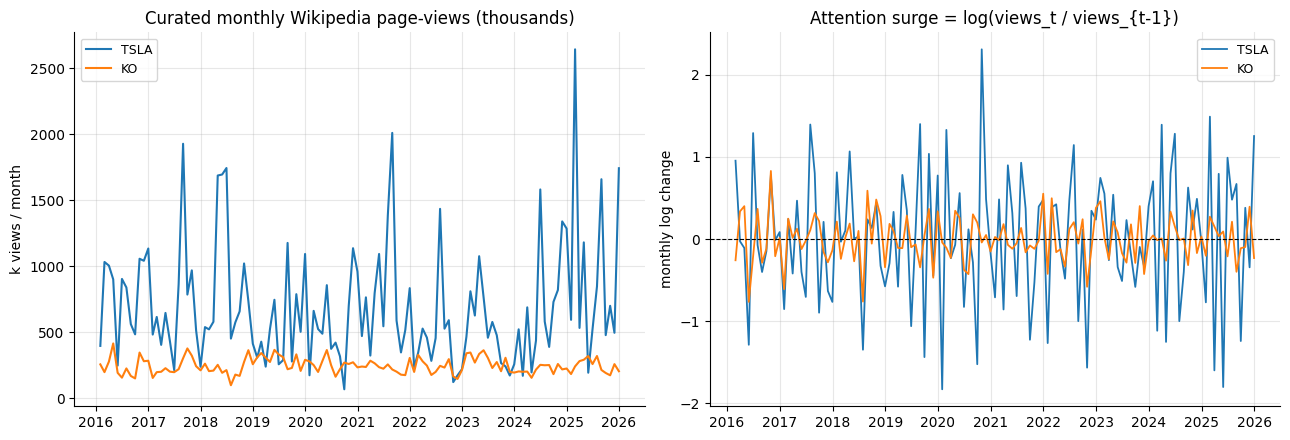

A 'surge' is a positive spike; a 'drought' is a negative one. We rank the basket on this each month.


In [3]:
# Show a couple of names' page-view paths and their month-over-month surge
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
show = [c for c in ["TSLA", "KO"] if c in views.columns][:2] or list(views.columns[:2])
ax = axes[0]
for c in show:
    ax.plot(views.index, views[c] / 1000.0, lw=1.5, label=c)
ax.set_title("Curated monthly Wikipedia page-views (thousands)")
ax.set_ylabel("k views / month"); ax.legend(fontsize=9)

ax = axes[1]
for c in show:
    ax.plot(sur.index, sur[c], lw=1.3, label=c)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Attention surge = log(views_t / views_{t-1})")
ax.set_ylabel("monthly log change"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("A 'surge' is a positive spike; a 'drought' is a negative one. We rank the basket on this each month.")


## The drought-vs-surge race

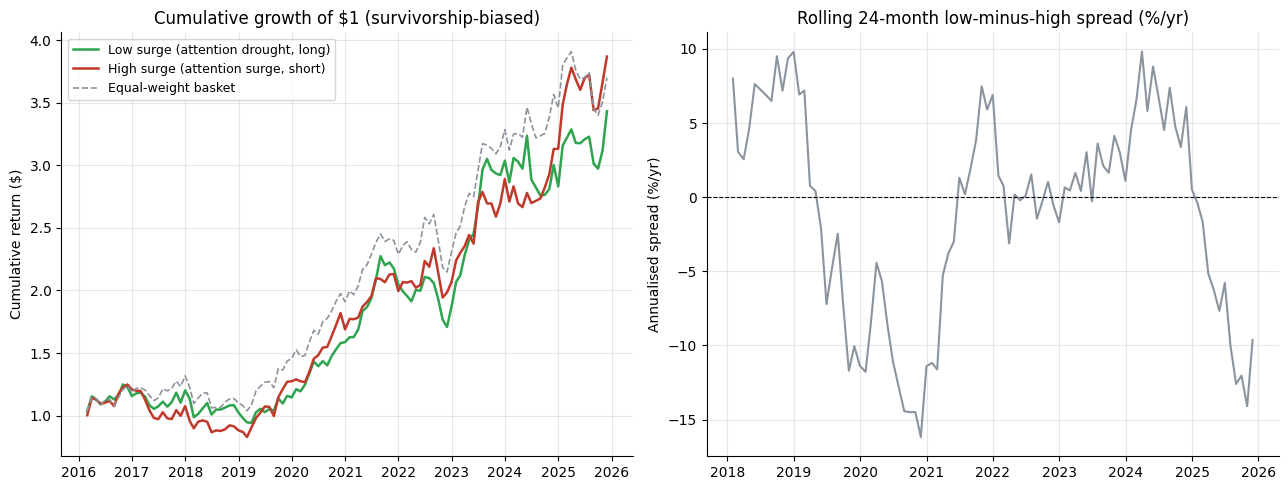

Drought-minus-surge spread: -1.2%/yr = -10.2bps/mo  HAC t = -0.31
The two legs are tangled together -- there is no persistent edge either way.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative growth of the two legs
ax = axes[0]
cum_low  = (1 + res["low"].dropna()).cumprod()
cum_high = (1 + res["high"].dropna()).cumprod()
cum_mkt  = (1 + res["market"].dropna()).cumprod()
ax.plot(cum_low.index,  cum_low.values,  color=GREEN, lw=1.8, label="Low surge (attention drought, long)")
ax.plot(cum_high.index, cum_high.values, color=RED,   lw=1.8, label="High surge (attention surge, short)")
ax.plot(cum_mkt.index,  cum_mkt.values,  color=GREY,  lw=1.2, ls="--", label="Equal-weight basket")
ax.set_title("Cumulative growth of $1 (survivorship-biased)")
ax.set_ylabel("Cumulative return ($)"); ax.legend(fontsize=9)

# Rolling 24-month spread
ax = axes[1]
roll = spread.rolling(24).mean() * 1200
ax.plot(roll.index, roll.values, color=GREY, lw=1.5)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Rolling 24-month low-minus-high spread (%/yr)")
ax.set_ylabel("Annualised spread (%/yr)")
plt.tight_layout(); plt.show()
print(f"Drought-minus-surge spread: {R['spread_ann']:+.1f}%/yr = {R['spread_bps']:+.1f}bps/mo  HAC t = {R['spread_t']:+.2f}")
print("The two legs are tangled together -- there is no persistent edge either way.")


## The bottom line for the curious

The headline is a **non-event**: betting on the Wikipedia-views surge reversal produces a
spread of **-1.2%/yr** with HAC *t* = **-0.31** -- statistically indistinguishable from
zero, and with the *wrong sign* (the high-surge leg edged slightly ahead).

Why does the famous "Wikipedia predicts markets" result evaporate here?

- **Wrong frequency**: the published effects are *days to two weeks*; a monthly rebalance
  averages them away.
- **Wrong universe**: attention effects are strongest in *small, retail-heavy* names; a
  liquid mega-cap basket has every effect already arbitraged.
- **Spike-dominated data**: one news event swamps the page-view series, so the "surge"
  is mostly noise about a one-off headline, not a tradable state.

This is a **None / Mirage** -- a fun big-data folklore that does not hold up as a monthly
cross-sectional signal.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*